In [45]:
from pathlib import Path
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import sleap_io as sio

#### Metadata

In [46]:
experiment = "abcEphysPilot01"
arena = "AEON3"
session = "2026-04-14T141851Z_calibrateBeforeAprilExperiments"
chunk = "2026-04-14T14-00-00"

predictions_dir = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/"
    "abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions"
)

OUT_DIR = Path(f"/Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/{experiment}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

H_npz = next(OUT_DIR.glob("homographies_top_to_sides_ransac_thresh*.npz"))
roi_json = OUT_DIR / "soft_rois_top.json"

raw_video_root = Path("/Volumes/aeon/aeon/data/raw")  # change if needed

camera_top = "CameraTop"
side_cameras = ["CameraNorth", "CameraSouth", "CameraEast", "CameraWest"]
camera_nest = "CameraNest"  # override when inside Nest ROI

# Grid resolution for preference map
grid_step_px = 10  # 10x10 pixel spots on Top view

# Top SLEAP quality threshold (only affects whether we trust Top card center)
top_conf_threshold = 0.6

### Load in data

In [ ]:
# helper functions
def build_video_path(camera: str) -> Path:
    return raw_video_root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"

def open_cap(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(f"Could not open video: {video_path}")
    return cap

def read_frame(video_path: Path, frame_idx: int) -> np.ndarray:
    cap = open_cap(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_idx} from {video_path}")
    return frame  # BGR

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

#### Load in ROIs from .json file

In [48]:
roi_payload = json.loads(roi_json.read_text())
rois = roi_payload["rois"]

nest_roi = None
for r in rois:
    if r.get("camera") == camera_nest and r.get("type") == "rect":
        nest_roi = r
        break

assert nest_roi is not None, f"Could not find Nest rect ROI for {camera_nest} in {roi_json}"

def point_in_rect(xy, x0y0, x1y1):
    x, y = float(xy[0]), float(xy[1])
    x0, y0 = x0y0
    x1, y1 = x1y1
    x_min, x_max = (x0, x1) if x0 <= x1 else (x1, x0)
    y_min, y_max = (y0, y1) if y0 <= y1 else (y1, y0)
    return (x_min <= x <= x_max) and (y_min <= y <= y_max)

print("Nest ROI:", nest_roi)

Nest ROI: {'name': 'Nest', 'camera': 'CameraNest', 'type': 'rect', 'x0y0': [1235.0, 465.0], 'x1y1': [1345.0, 595.0], 'sigma_px': 0.0, 'priority': 10}


#### Load in top->side mapping

In [49]:
zH = np.load(H_npz)

# Get Top size
top_video_path = build_video_path(camera_top)
top0 = read_frame(top_video_path, 0)
top_h, top_w = top0.shape[:2]
print("Top size:", (top_w, top_h))

# Get each side cam size and its H
cam_wh = {}
H_top_to_cam = {}

for cam in side_cameras:
    vp = build_video_path(cam)
    fr0 = read_frame(vp, 0)
    h, w = fr0.shape[:2]
    cam_wh[cam] = (w, h)

    key = f"{cam}__H_top_to_side"
    assert key in zH, f"Missing homography key {key} in {H_npz}"
    H_top_to_cam[cam] = zH[key]

# Nest size too (for video rendering; not used for mapping here)
nest_vp = build_video_path(camera_nest)
nest0 = read_frame(nest_vp, 0)
nest_h, nest_w = nest0.shape[:2]
print("Nest size:", (nest_w, nest_h))

Top size: (1440, 1080)
Nest size: (720, 540)


In [ ]:
# remapping helper functions
def apply_homography(H: np.ndarray, xy: np.ndarray) -> np.ndarray:
    xy = np.asarray(xy, dtype=np.float64)
    ones = np.ones((xy.shape[0], 1), dtype=np.float64)
    X = np.concatenate([xy, ones], axis=1)       # (N,3)
    Y = (H @ X.T).T                               # (N,3)
    return Y[:, :2] / Y[:, 2:3]                   # (N,2)

def center_distance_norm(xy_cam, wh):
    w, h = wh
    cx, cy = w / 2.0, h / 2.0
    x, y = float(xy_cam[0]), float(xy_cam[1])

    # normalize so edge ~1, corners ~1.4
    dx = (x - cx) / (w / 2.0)
    dy = (y - cy) / (h / 2.0)
    return float(np.hypot(dx, dy))

def in_bounds(xy_cam, wh, margin=0.0):
    w, h = wh
    x, y = float(xy_cam[0]), float(xy_cam[1])
    return (margin <= x <= (w - 1 - margin)) and (margin <= y <= (h - 1 - margin))

## Build preference heatmap on the Top camera view

In [51]:
xs = np.arange(0, top_w, grid_step_px, dtype=int)
ys = np.arange(0, top_h, grid_step_px, dtype=int)

best_cam_idx = np.full((len(ys), len(xs)), -1, dtype=int)   # which side cam wins
best_score = np.full((len(ys), len(xs)), np.inf, dtype=float)

for yi, y in enumerate(ys):
    pts_top = np.stack([xs.astype(float), np.full_like(xs, float(y))], axis=1)  # (len(xs),2)

    for ci, cam in enumerate(side_cameras):
        pts_cam = apply_homography(H_top_to_cam[cam], pts_top)  # (len(xs),2)

        for xi in range(len(xs)):
            p = pts_cam[xi]
            if not in_bounds(p, cam_wh[cam], margin=5.0):
                continue
            s = center_distance_norm(p, cam_wh[cam])
            if s < best_score[yi, xi]:
                best_score[yi, xi] = s
                best_cam_idx[yi, xi] = ci

print("Built preference map.")

Built preference map.


#### Plot preference map

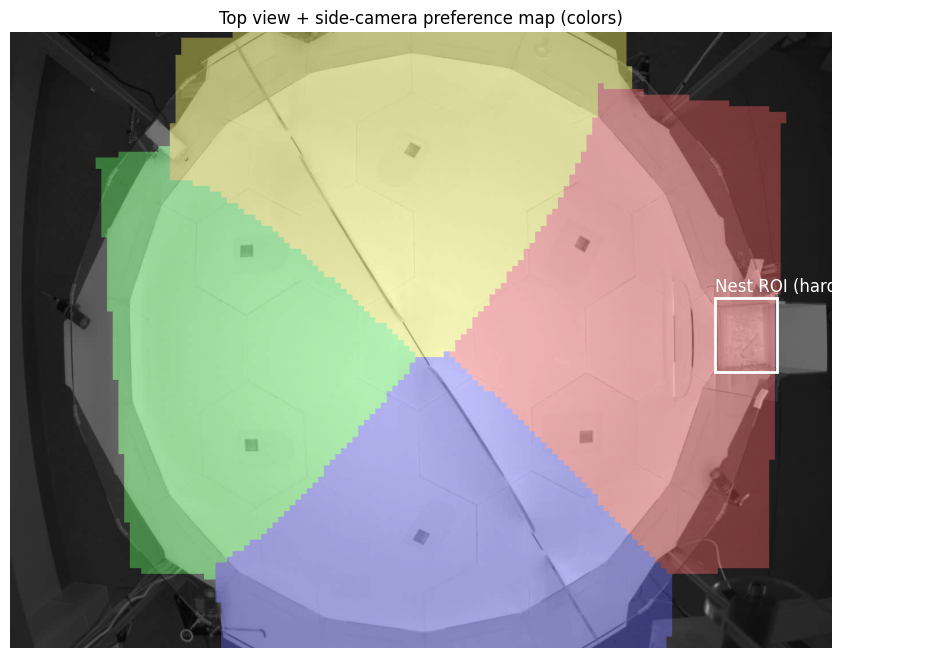

In [52]:
top_rgb = bgr_to_rgb(top0)

# Build a color image for the camera assignment map
cam_colors = {
    "CameraNorth": np.array([255, 80, 80]),   # reddish
    "CameraSouth": np.array([80, 255, 80]),   # greenish
    "CameraEast":  np.array([80, 80, 255]),   # bluish
    "CameraWest":  np.array([255, 255, 80]),  # yellowish
}
color_map = np.zeros((len(ys), len(xs), 3), dtype=np.uint8)

for ci, cam in enumerate(side_cameras):
    mask = best_cam_idx == ci
    color_map[mask] = cam_colors[cam]

# Upsample to full Top size (nearest neighbor) for display
assign_full = cv2.resize(color_map, (top_w, top_h), interpolation=cv2.INTER_NEAREST)

# Draw Nest rectangle on top
x0, y0 = nest_roi["x0y0"]
x1, y1 = nest_roi["x1y1"]
x_min, x_max = (x0, x1) if x0 <= x1 else (x1, x0)
y_min, y_max = (y0, y1) if y0 <= y1 else (y1, y0)

overlay = (0.65 * top_rgb + 0.35 * assign_full).astype(np.uint8)

plt.figure(figsize=(12, 8))
plt.imshow(overlay)
plt.title("Top view + side-camera preference map (colors)")
plt.axis("off")
plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                 fill=False, edgecolor="white", linewidth=2))
plt.text(x_min, y_min-10, "Nest ROI (hard override)", color="white", fontsize=12)
plt.show()

## Calculate from SLEAP labelling the centre of object

In [53]:
NODE_ORDER = ["corner_1", "corner_2", "corner_3", "corner_4"]
NODE_TO_I = {n: i for i, n in enumerate(NODE_ORDER)}

def extract_top_centers(slp_path: Path, top_conf_threshold: float, top_T: int):
    labels = sio.load_file(slp_path)

    coords = np.full((top_T, 4, 2), np.nan, dtype=np.float32)
    scores = np.full((top_T, 4), np.nan, dtype=np.float32)

    for lf in labels.labeled_frames:
        t = int(lf.frame_idx)
        if t < 0 or t >= top_T or len(lf.instances) < 1:
            continue
        inst = lf.instances[0]
        pts = np.asarray(inst.points)
        for pt in pts:
            name = pt["name"]
            if name not in NODE_TO_I:
                continue
            i = NODE_TO_I[name]
            coords[t, i] = pt["xy"]
            scores[t, i] = float(pt["score"])

    all4 = np.isfinite(coords).all(axis=2).all(axis=1)
    min_score = np.nanmin(scores, axis=1)
    valid = all4 & np.isfinite(min_score) & (min_score >= top_conf_threshold)

    centers = np.full((top_T, 2), np.nan, dtype=np.float32)
    centers[valid] = np.nanmean(coords[valid], axis=1)

    return centers, valid

top_slp = next(predictions_dir.glob("CameraTop*.slp"))
centers_top, centers_valid = extract_top_centers(top_slp, top_conf_threshold=top_conf_threshold, top_T=top_h*0 + int(zH[list(zH.keys())[0]].shape[0]) )

/var/folders/dx/rxyhq6ns3zg19nylykcr_c940000gn/T/ipykernel_75572/3425191818.py:25: RuntimeWarning: All-NaN slice encountered
  min_score = np.nanmin(scores, axis=1)


In [54]:
# correct T from Top video
cap = open_cap(top_video_path)
T = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print("Top video T:", T)

centers_top, centers_valid = extract_top_centers(top_slp, top_conf_threshold=top_conf_threshold, top_T=T)
print("Valid Top centers:", int(np.sum(centers_valid)))

Top video T: 29584
Valid Top centers: 9810


/var/folders/dx/rxyhq6ns3zg19nylykcr_c940000gn/T/ipykernel_75572/3425191818.py:25: RuntimeWarning: All-NaN slice encountered
  min_score = np.nanmin(scores, axis=1)


#### Sanity check: is centre calculated correctly, is top->side translation working?

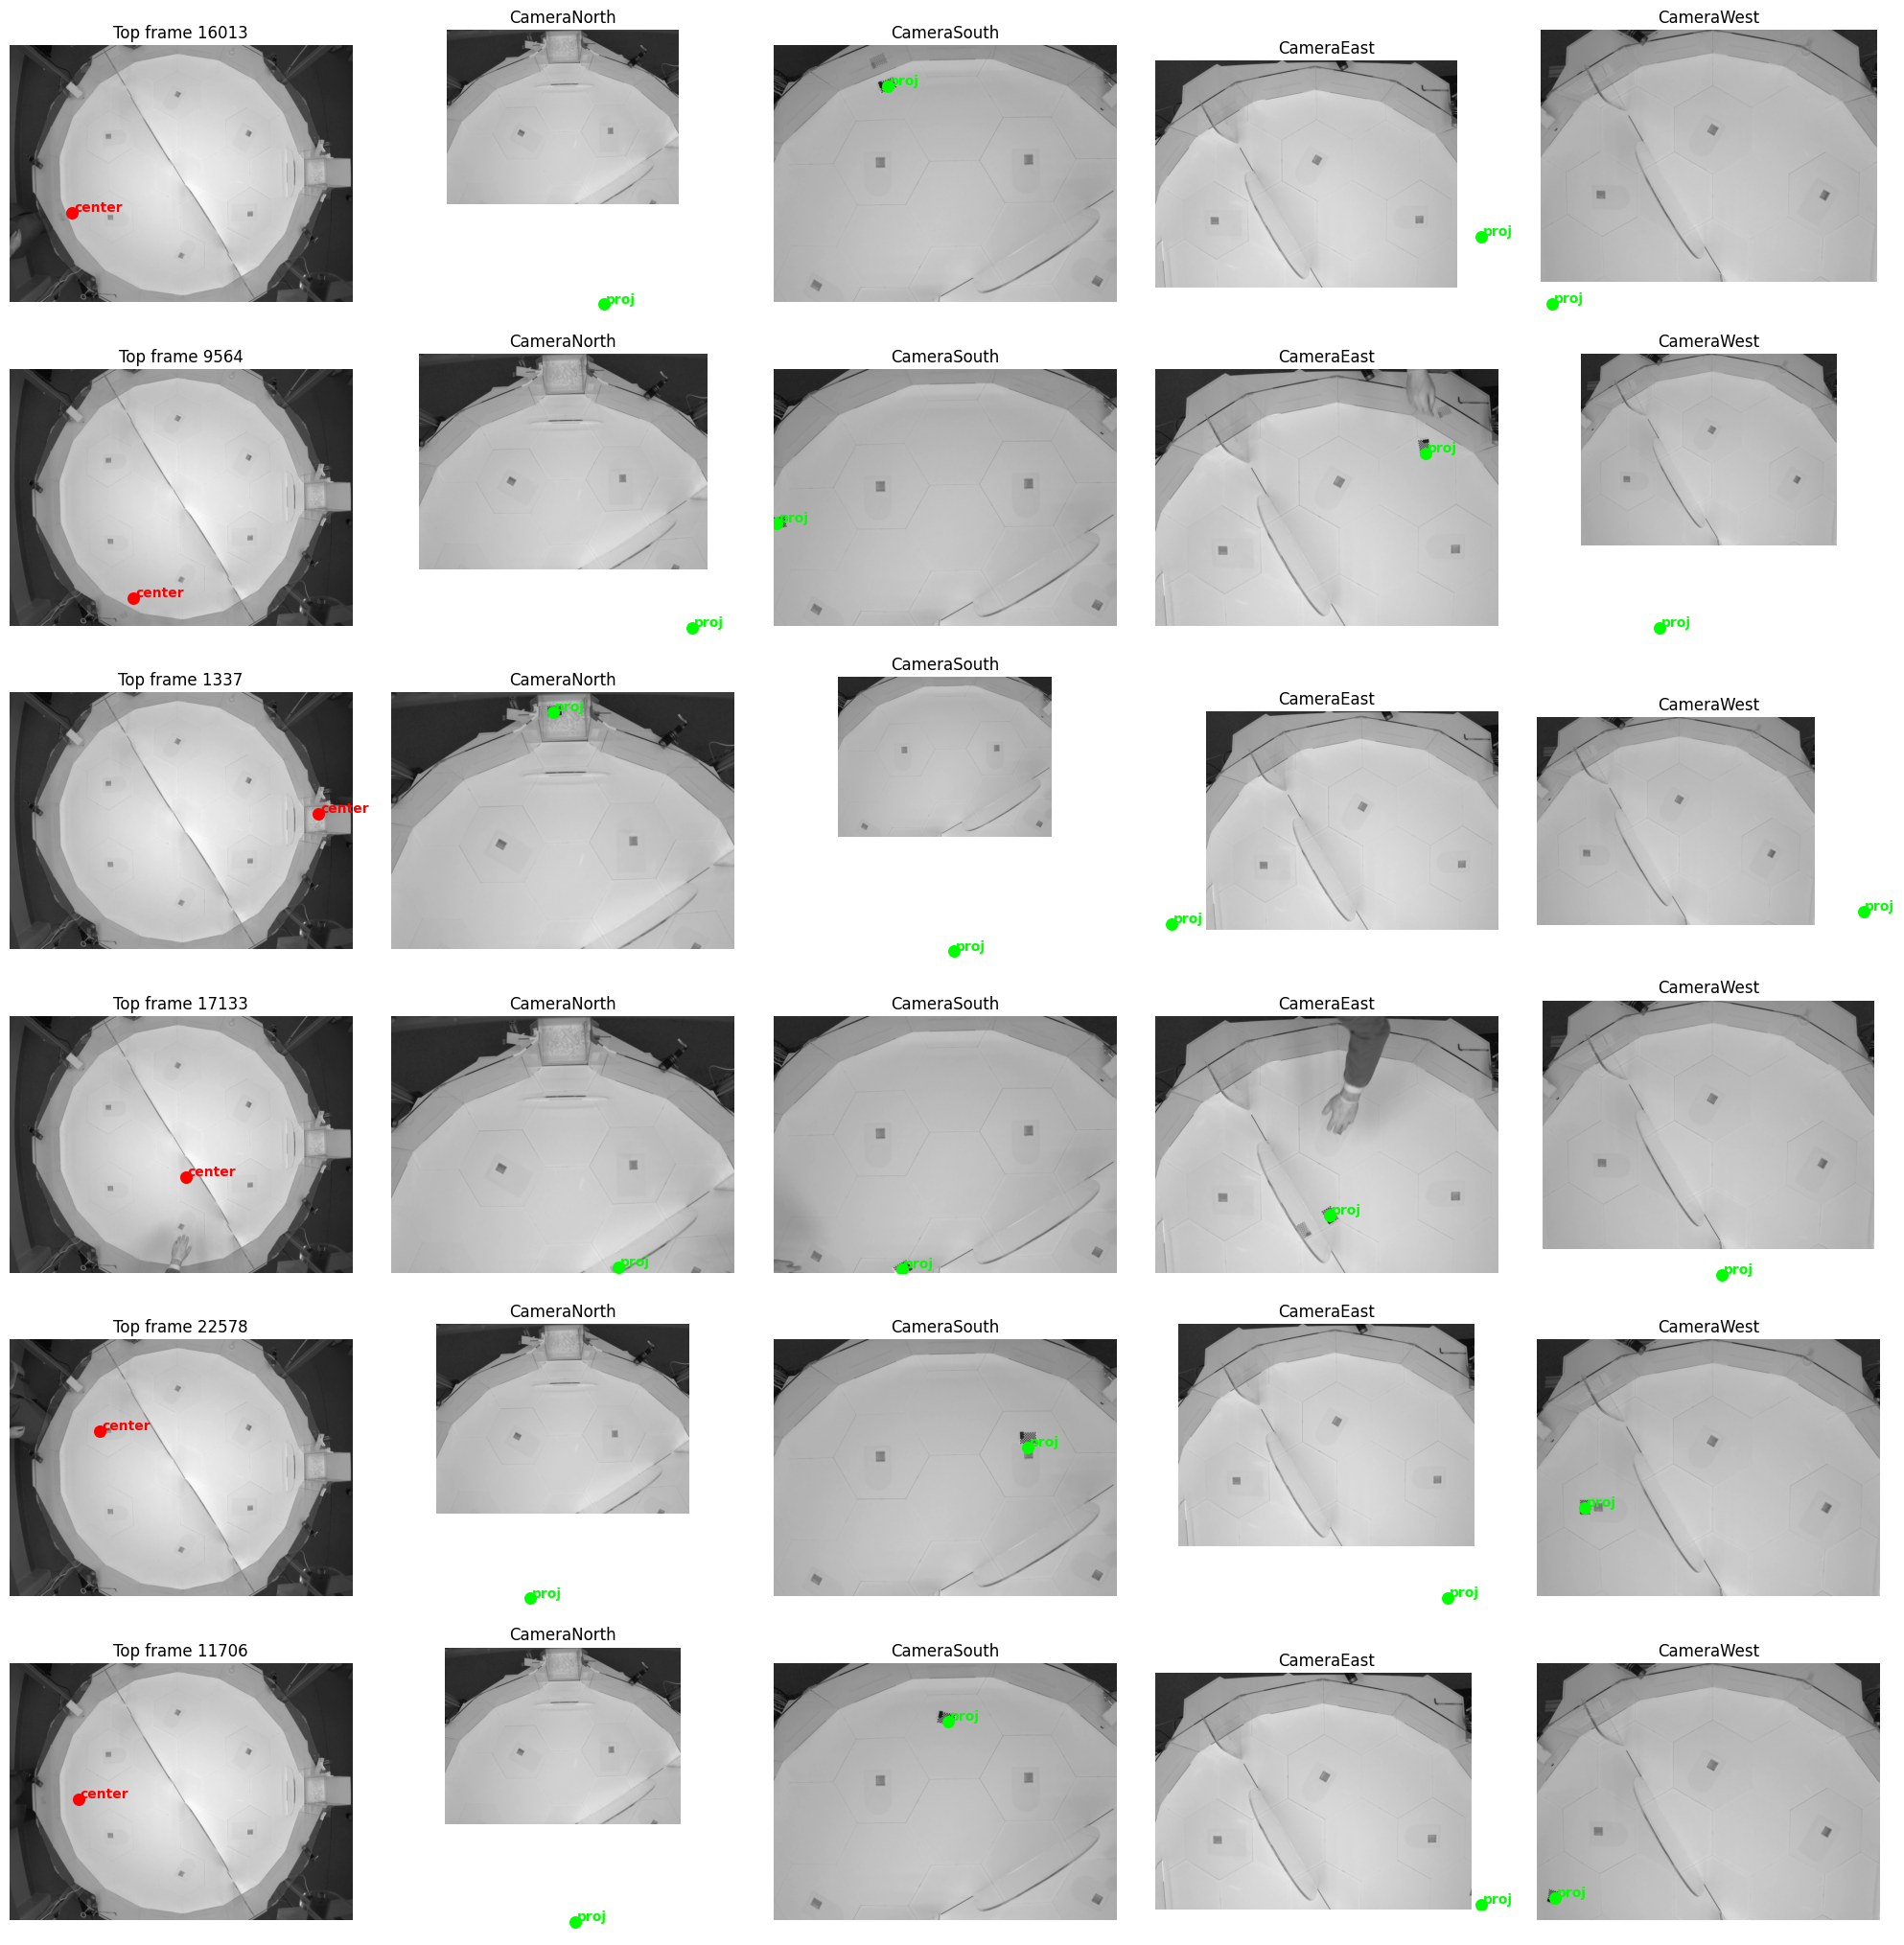

In [56]:
# Show Top + each Side camera frame for the same frame_idx,
# with the Top-derived center projected into each side view via H_top_to_side.
def show_top_and_sides_with_projected_center(
    frame_idxs,
    top_video_path: Path,
    side_cameras,
    build_video_path_fn,
    centers_top: np.ndarray,
    centers_valid: np.ndarray,
    H_top_to_cam: dict,        # cam -> 3x3 H_top_to_side
    cam_wh: dict,              # cam -> (w,h)
    cols=None,
):
    if cols is None:
        cols = 1 + len(side_cameras)  # Top + all sides

    # open caps once
    caps = {"Top": open_cap(top_video_path)}
    for cam in side_cameras:
        caps[cam] = open_cap(build_video_path_fn(cam))

    rows = len(frame_idxs)
    plt.figure(figsize=(4 * cols, 3.4 * rows))

    for r, t in enumerate(frame_idxs):
        t = int(t)

        # ---- read Top ----
        caps["Top"].set(cv2.CAP_PROP_POS_FRAMES, t)
        ok, top_bgr = caps["Top"].read()
        if not ok or top_bgr is None:
            continue
        top_rgb = bgr_to_rgb(top_bgr)

        cx, cy = centers_top[t] if centers_valid[t] else (np.nan, np.nan)

        # plot Top
        ax = plt.subplot(rows, cols, r * cols + 1)
        ax.imshow(top_rgb)
        ax.axis("off")
        ax.set_title(f"Top frame {t}")

        if np.isfinite([cx, cy]).all():
            ax.scatter([cx], [cy], s=70, c="red")
            ax.text(cx + 8, cy - 8, "center", color="red", fontsize=10, weight="bold")

        # ---- each side ----
        for j, cam in enumerate(side_cameras):
            caps[cam].set(cv2.CAP_PROP_POS_FRAMES, t)
            ok, side_bgr = caps[cam].read()
            if not ok or side_bgr is None:
                continue
            side_rgb = bgr_to_rgb(side_bgr)

            ax = plt.subplot(rows, cols, r * cols + (j + 2))
            ax.imshow(side_rgb)
            ax.axis("off")
            ax.set_title(cam)

            # project Top center into this side camera
            if np.isfinite([cx, cy]).all() and cam in H_top_to_cam:
                p = apply_homography(H_top_to_cam[cam], np.array([[cx, cy]], dtype=np.float64))[0]
                px, py = float(p[0]), float(p[1])

                ax.scatter([px], [py], s=70, c="lime")
                ax.text(px + 8, py - 8, "proj", color="lime", fontsize=10, weight="bold")

    plt.tight_layout()
    plt.show()

    for cap in caps.values():
        cap.release()


# Example usage: pick a few frames (random or explicit)
rng = np.random.default_rng(40)
valid_idxs = np.where(centers_valid)[0]
frame_idxs = rng.choice(valid_idxs, size=6, replace=False)

show_top_and_sides_with_projected_center(
    frame_idxs=frame_idxs,
    top_video_path=build_video_path(camera_top),
    side_cameras=side_cameras,
    build_video_path_fn=build_video_path,
    centers_top=centers_top,
    centers_valid=centers_valid,
    H_top_to_cam=H_top_to_cam,
    cam_wh=cam_wh,
)

## Based on object centre, get best camera at each frame

In [57]:
def lookup_best_side_cam(center_xy):
    x, y = float(center_xy[0]), float(center_xy[1])
    xi = int(np.clip(np.round(x / grid_step_px), 0, len(xs) - 1))
    yi = int(np.clip(np.round(y / grid_step_px), 0, len(ys) - 1))
    ci = int(best_cam_idx[yi, xi])
    if ci < 0:
        return None
    return side_cameras[ci]

selected_cam = np.full((T,), "", dtype=object)

last_cam = side_cameras[0]
for t in range(T):
    if not centers_valid[t]:
        selected_cam[t] = last_cam
        continue

    cxy = centers_top[t]

    # Nest override
    if point_in_rect(cxy, nest_roi["x0y0"], nest_roi["x1y1"]):
        selected_cam[t] = camera_nest
        last_cam = camera_nest
        continue

    cam = lookup_best_side_cam(cxy)
    if cam is None:
        selected_cam[t] = last_cam
    else:
        selected_cam[t] = cam
        last_cam = cam

# Quick counts
from collections import Counter
print(Counter(selected_cam))

Counter({'CameraEast': 7904, 'CameraNorth': 7775, 'CameraSouth': 6494, 'CameraWest': 6293, 'CameraNest': 1118})


### Plot camera changes

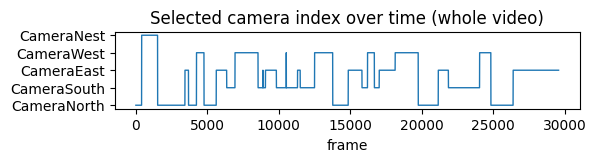

In [63]:
# Selected camera over time (whole video)
cams_plot = side_cameras + [camera_nest]  # expected set in this simplified notebook
idx_series = [
    cams_plot.index(c) if c in cams_plot else np.nan
    for c in selected_cam
]
plt.figure(figsize=(6, 1))
plt.plot(idx_series, linewidth=1.0)
plt.yticks(range(len(cams_plot)), cams_plot)
plt.title("Selected camera index over time (whole video)")
plt.xlabel("frame")
plt.show()

## Composite video

### Make short video for testing

In [ ]:
test_start = 1000
test_len = 5000
test_end = min(T - 1, test_start + test_len - 1)

test_out = OUT_DIR / f"composite_test_map_{test_start}_{test_end}.mp4"
output_fps = 30

print("Writing:", test_out)
print("Frames:", test_start, "->", test_end)

# Output size: use Top size
out_h, out_w = top_h, top_w

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(test_out), fourcc, output_fps, (out_w, out_h))
assert writer.isOpened(), "VideoWriter failed to open."

def overlay_text(frame_bgr, text, xy=(20, 40)):
    cv2.putText(frame_bgr, text, xy, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2, cv2.LINE_AA)
    return frame_bgr

# Keep a cache of open VideoCaptures for speed (only a few cams)
caps = {}
def get_cap(cam):
    if cam in caps:
        return caps[cam]
    cap = open_cap(build_video_path(cam))
    caps[cam] = cap
    return cap

frames_written = 0
for t in range(test_start, test_end + 1):
    cam = selected_cam[t]
    cap = get_cap(cam)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t))
    ok, frame = cap.read()
    if not ok or frame is None:
        continue

    # Resize camera frames (e.g., Nest) into Top size
    if frame.shape[0] != out_h or frame.shape[1] != out_w:
        frame = cv2.resize(frame, (out_w, out_h), interpolation=cv2.INTER_LINEAR)

    # annotate
    frame = overlay_text(frame, f"{cam} | t={t}")

    # draw center marker (for debugging)
    if centers_valid[t]:
        cx, cy = centers_top[t]
        if cam == camera_top:
            px, py = float(cx), float(cy)
        elif cam in H_top_to_cam:
            px, py = apply_homography(H_top_to_cam[cam], np.array([[cx, cy]], dtype=np.float64))[0]
        else:
            px, py = None, None
        # if we have a valid projected point, draw it
        if px is not None and np.isfinite([px, py]).all():
            # if you resized the frame, also scale the point
            if (frame.shape[1], frame.shape[0]) != (out_w, out_h):
                # (in your code you resize frame to out_w/out_h, so instead compute scaling BEFORE resize)
                pass
            cv2.circle(frame, (int(px), int(py)), 8, (0, 0, 255), -1)

    writer.write(frame)
    frames_written += 1
    if frames_written % 200 == 0:
        print("written", frames_written)

writer.release()
for cap in caps.values():
    cap.release()

print("Done. Saved:", test_out)

Writing: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/composite_test_map_1000_5999.mp4
Frames: 1000 -> 5999
written 200
written 400
written 600
written 800
written 1000
written 1200
written 1400
written 1600
written 1800
written 2000
written 2200
written 2400
written 2600
written 2800
written 3000
written 3200
written 3400
written 3600
written 3800
written 4000
written 4200
written 4400
written 4600
written 4800
written 5000
Done. Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/composite_test_map_1000_5999.mp4


### Make full composite video

In [60]:
start = 0
end = T - 1

out_path = OUT_DIR / f"composite_full_map.mp4"
output_fps = 30

print("Writing:", out_path)
print("Frames:", start, "->", end)

# Output size: use Top size
out_h, out_w = top_h, top_w

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, output_fps, (out_w, out_h))
assert writer.isOpened(), "VideoWriter failed to open."

def overlay_text(frame_bgr, text, xy=(20, 40)):
    cv2.putText(frame_bgr, text, xy, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2, cv2.LINE_AA)
    return frame_bgr

# Keep a cache of open VideoCaptures for speed
caps = {}
def get_cap(cam):
    if cam in caps:
        return caps[cam]
    cap = open_cap(build_video_path(cam))
    caps[cam] = cap
    return cap

frames_written = 0

for t in range(start, end + 1):
    cam = selected_cam[t]
    cap = get_cap(cam)

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t))
    ok, frame = cap.read()
    if not ok or frame is None:
        continue

    # Compute marker point in THIS camera's coordinates (before resize)
    px_py = None
    if centers_valid[t]:
        cx, cy = centers_top[t]
        if cam == camera_top:
            px_py = (float(cx), float(cy))
        elif cam in H_top_to_cam:
            p = apply_homography(H_top_to_cam[cam], np.array([[cx, cy]], dtype=np.float64))[0]
            if np.isfinite(p).all():
                px_py = (float(p[0]), float(p[1]))

    # Resize to output size (and scale marker if needed)
    h0, w0 = frame.shape[:2]
    if h0 != out_h or w0 != out_w:
        sx = out_w / w0
        sy = out_h / h0
        frame = cv2.resize(frame, (out_w, out_h), interpolation=cv2.INTER_LINEAR)
        if px_py is not None:
            px_py = (px_py[0] * sx, px_py[1] * sy)

    # annotate
    frame = overlay_text(frame, f"{cam} | t={t}")

    # draw marker
    if px_py is not None:
        px, py = px_py
        cv2.circle(frame, (int(px), int(py)), 8, (0, 0, 255), -1)

    writer.write(frame)
    frames_written += 1

    if frames_written % 500 == 0:
        print("written", frames_written)

writer.release()
for cap in caps.values():
    cap.release()

print("Done. Saved:", out_path)
print("Frames written:", frames_written)

Writing: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/composite_full_map.mp4
Frames: 0 -> 29583
written 500
written 1000
written 1500
written 2000
written 2500
written 3000
written 3500
written 4000
written 4500
written 5000
written 5500
written 6000
written 6500
written 7000
written 7500
written 8000
written 8500
written 9000
written 9500
written 10000
written 10500
written 11000
written 11500
written 12000
written 12500
written 13000
written 13500
written 14000
written 14500
written 15000
written 15500
written 16000
written 16500
written 17000
written 17500
written 18000
written 18500
written 19000
written 19500
written 20000
written 20500
written 21000
written 21500
written 22000
written 22500
written 23000
written 23500
written 24000
written 24500
written 25000
written 25500
written 26000
written 26500
written 27000
written 27500
written 28000
written 28500
written 29000
written 29500
Done. Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_out